 # Portuguese Bank Term Deposit Prediction using Machine Learning
 
## Domain: Finance / Banking

To build a predictive machine learning model that can **predict whether a customer will subscribe to a term deposit (Yes/No)** before making a call.


## Problem Statement

This project focuses on **analyzing a Portuguese bank’s telemarketing campaign data** to predict whether a customer will subscribe to a term deposit.

The bank conducted direct marketing campaigns between 2008 and 2010. The goal is to build a predictive model that helps the marketing team identify high-potential customers before making a call.

By predicting customer subscription probability, the bank can:

- Identify which customers are more likely to subscribe to a term deposit.
- Reduce unnecessary calls
- Save marketing cost
- Improve conversion rate
- Increase Return on Investment (ROI)

Target variable y has two categories:

- Yes -> Customer subscribed
- No -> Customer did not subscribe

This is a **Binary Classification Problem**

### Aim & Objectives 

To analyze customer and campaign data and develop a predictive classification model that accurately **predicts term deposit subscription.**

**Objectives:**

- Perform complete exploratory data analysis (EDA).
- Understand customer behavior patterns.
- Identify important features influencing subscription.
- Handle categorical variables properly.
- Build multiple classification models.
- Select best production model.
- Perform hyperparameter tuning to improve accuracy.
- Suggest actionable business insights for marketing team.

## Dataset Description

The dataset used in this project is the **Bank Marketing Dataset,** which contains data related to direct marketing campaigns conducted by a Portuguese banking institution. The campaigns were **performed through phone calls to promote term deposit subscriptions.**

- Total Records: 41,188
- Total Features: **20 Input Features + 1 Target Variable**
- Data collected from real marketing campaigns.

Data contains:
- Customer information
- Campaign information
- Economic indicators

**Target Variable: y**
- Yes = Customer subscribed
- No = Customer not subscribed.


## Import Required Libraries

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# save model
import pickle

import warnings
warnings.filterwarnings("ignore")

**Insight:**
  
These libraries helps in:

- data handling
- visualization
- model building
- SMOTE for imbalance handling
- evaluation, and saving models.

## Load the Dataset

In [2]:
df = pd.read_csv("bank-additional-full.csv", sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


**Insights**

- Data loaded successfully
- They use ; as column separator
- If we don’t specify sep=';', **pandas will treat the entire row as one single column,** which is wrong.
- Both categorical and numerical features present.
- Target variable: y                                                                                      

### Domain Analysis

The **Banking and Financial** Services domain focuses on managing **customer relationships, increasing revenue, and minimizing financial risk.**
One of the major challenges in banking is improving the **success rate of marketing campaigns** for financial products such as term deposits.

Term deposits are fixed-income investment products where customers deposit money for a fixed period and earn interest. 
Banks conduct telemarketing campaigns to promote these products. However, contacting all customers is costly and inefficient.

Machine Learning in banking helps to:
- Identify customers who are most likely to subscribe to a term deposit
- Reduce marketing costs by targeting high-probability customers
- Improve campaign success rate
- Minimize financial risk

## Basic Data Understanding

In [3]:
# Display the first 5 rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Display the last 5 rows
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [5]:
# Display the size of dataset
df.shape

(41188, 21)

**Insight:**

- The dataset in 41188 rows
- Dataset contains 21 columns
- Target variable: y (yes/no)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
# Statistical Summary
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Insights:**

statistical summary of all numerical features in the dataset.
- Data distribution
- Central tendency (mean, median)
- Spread of data (stadard diviations)
- Scale differences between variables

## Data Cleaning

In [8]:
# Check for missing values
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

**Insight:**

- Dataset contains **no missing values,** and its clean and No imputation needed.
- But "unknown" treated as categorical missing value
- We handle during encoding

In [9]:
# checks for Duplicate Records

df.duplicated().sum()

np.int64(12)

In [10]:
# Remove duplicate rows

df = df.drop_duplicates()

In [11]:
# Check again duplicates 
df.duplicated().sum()

np.int64(0)

**Insights:**

Remove duplicate rows because:

- They do not add new information in banking, marketing.
- They can bias the model
- They may inflate accuracy artificially
- They affect class distribution

In [12]:
# Drop irrelevant column(Data Leakage Feature)

df.drop("duration", axis=1, inplace=True)

**Insights:**

- Duration **highly impacts the target variable** but is not available before the call. So for realistic prediction, we remove it to **avoid data
  leakage.**
- The duration feature was removed from the analysis because it represents the length of the call, which is only known after the call has ended. Including this feature would cause data leakage and produce unrealistic model performance.

#### Handle Unknown Values

In [13]:
# replace the unKnown values to NAN
df.replace("unknown", np.nan, inplace=True)

# fill the mode values to the NAN (null values)
df.fillna(df.mode().iloc[0], inplace=True)

## Exploratory Data Analysis (EDA)

In [14]:
# Target Variable Distribution 

df["y"].value_counts()

y
no     36537
yes     4639
Name: count, dtype: int64

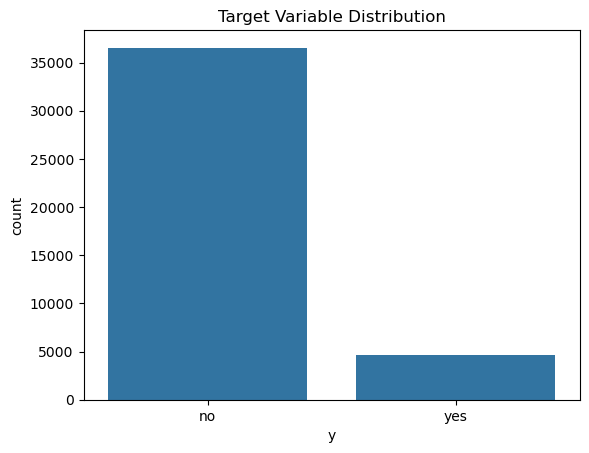

In [15]:
# Target Variable Distribution
sns.countplot(x="y", data=df)
plt.title("Target Variable Distribution")
plt.show()

**Insights:**
  
- Data is highly imbalanced.
- Majority customers did not subscribe to the term deposit.
- Minority class is "Yes".
- Imbalance handling required using (SMOTE).     

### Age Distribution Analysis

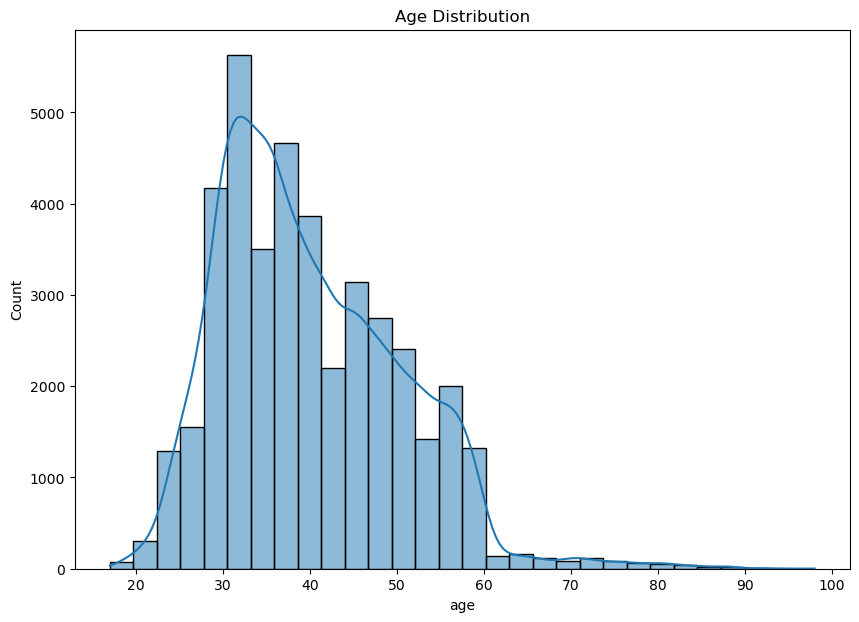

In [16]:
plt.figure(figsize=(10,7))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

**Insight:**

- Most customers are between 30–50 years
- Very few young and very old customers
- Distribution is slightly right skewed.
- Target audience mostly middle-aged
-The majority of customers fall between 30 and 50 years of age, indicating that middle-aged individuals are the primary target audience for the bank's marketing campaigns.

### Categorical Analysis
#### Job vs Subscription

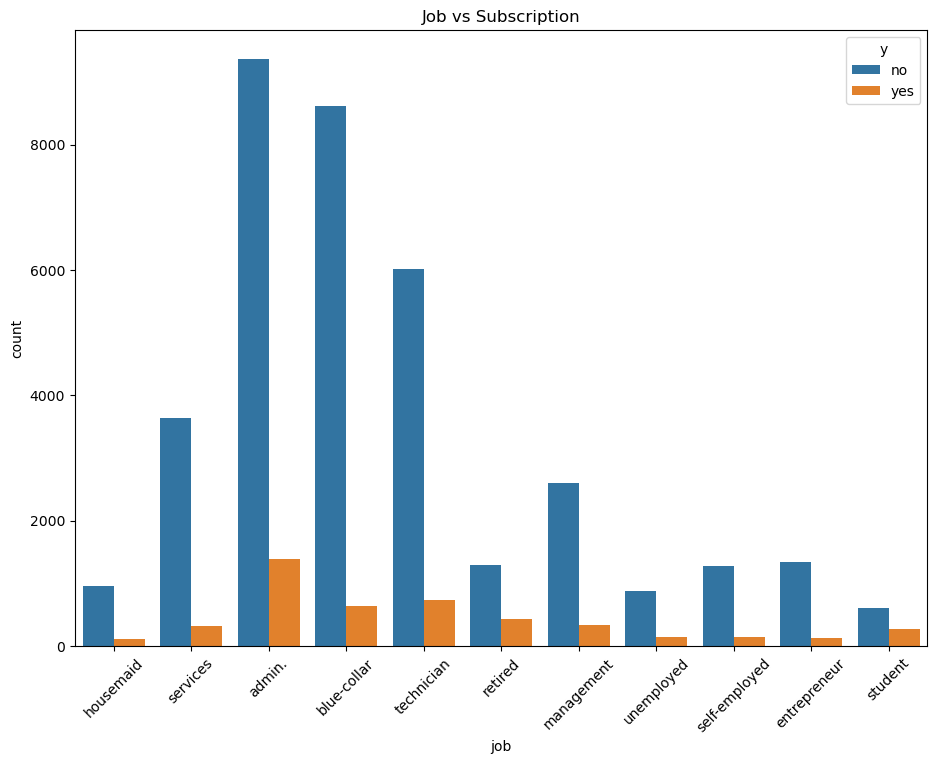

In [17]:
plt.figure(figsize=(11,8))
sns.countplot(x='job', hue='y', data=df)
plt.title("Job vs Subscription")
plt.xticks(rotation=45)                         #rotate the labels on the X-axis.   
plt.show()

**Insights:**

- Students & retired have higher subscription ratio
- Blue-colour mostly say NO
- Target retired & students for better campaign success
- Customers working in administrative, technician, and blue-collar jobs represent the largest portion of the dataset.

### Previous Campaign Outcome vs Subscription

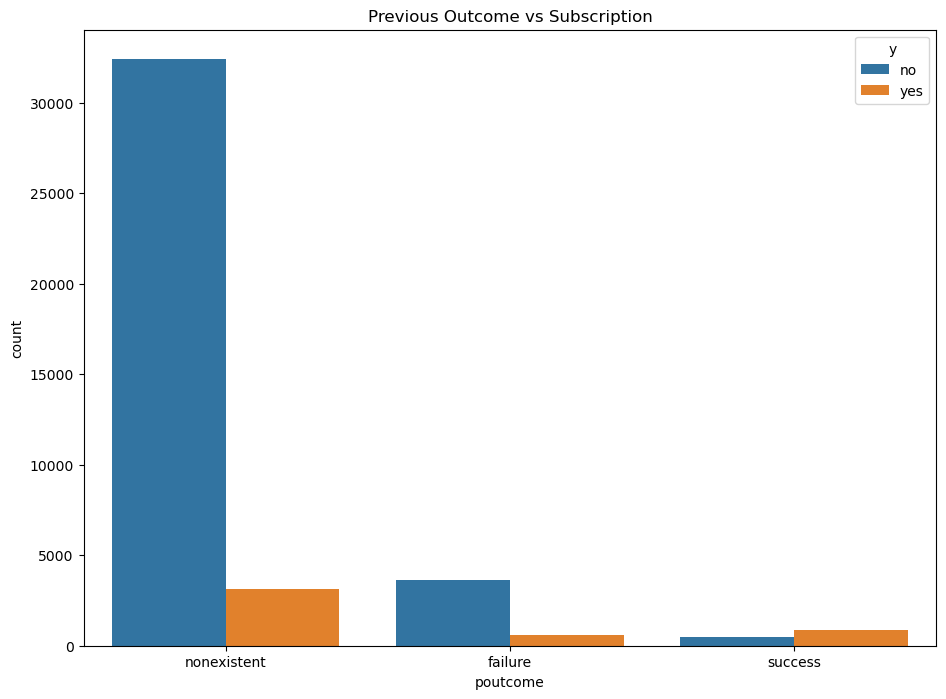

In [18]:
plt.figure(figsize=(11,8))
sns.countplot(x='poutcome', hue='y', data=df)
plt.title("Previous Outcome vs Subscription")
plt.show()

**Insight:**

- Customers who previously subscribed (success) show very high chance of subscribing again.
- Customers with previous failure show very low conversion.
- Nonexistent previous campaign -> moderate probability.
- Customers who previously had a successful marketing outcome were more likely to subscribe again.

### Age vs Campaign

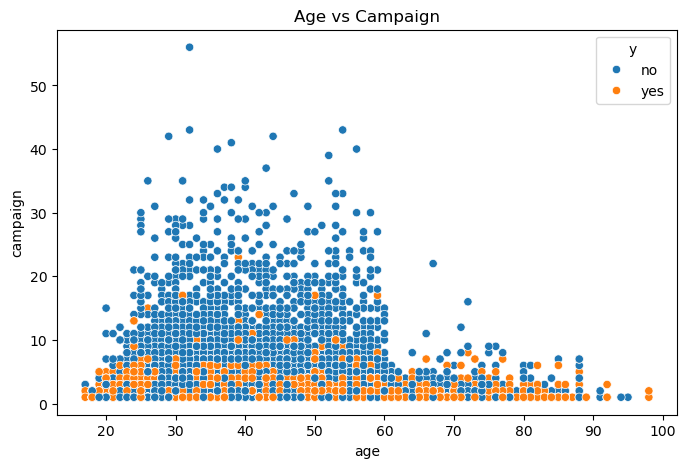

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='campaign', hue='y', data=df)
plt.title("Age vs Campaign")
plt.show()

**Insight:**

- No strong linear relationship.
- Customers contacted fewer times tend to subscribe more.
- High campaign number doesn’t guarantee success.
- Customers contacted fewer times during the campaign were more likely to subscribe, while repeated contacts often reduced the probability of subscription.

### Campaign Contacts

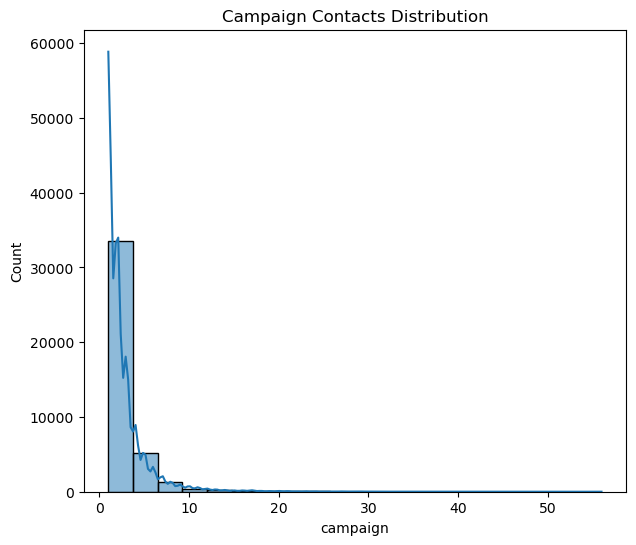

In [20]:
plt.figure(figsize=(7,6))
sns.histplot(df['campaign'], bins=20, kde=True)
plt.title("Campaign Contacts Distribution")
plt.show()

**Insight:**

- Most customers were contacted 1–3 times.
- Very high contact numbers may indicate aggressive marketing.
- Too many calls may reduce customer interest.

### Correlation Heatmap

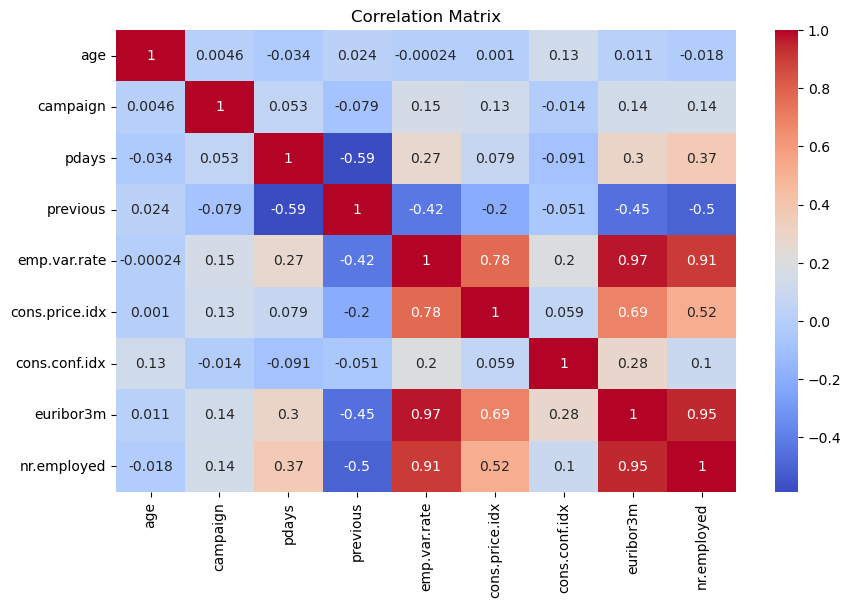

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Insight:**

- Euribor3m highly correlated with employment variables.
- No strong correlation between age and target.
- Economic indicators play important role.

In [22]:
# Dropping highly correlated features
df = df.drop(['emp.var.rate', 'nr.employed'], axis=1)

**Insight:**

- The correlation heatmap shows that **emp.var.rate, euribor3m, and nr.employed are highly correlated.**
- The correlation values are above 0.9, indicating strong multicollinearity.
- Highly correlated features can negatively impact model performance.
- To avoid redundancy, we removed emp.var.rate and nr.employed.
- We kept euribor3m because it represents the economic trend effectively.

In [23]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no


### Pair Plot Analysis

<Figure size 1000x600 with 0 Axes>

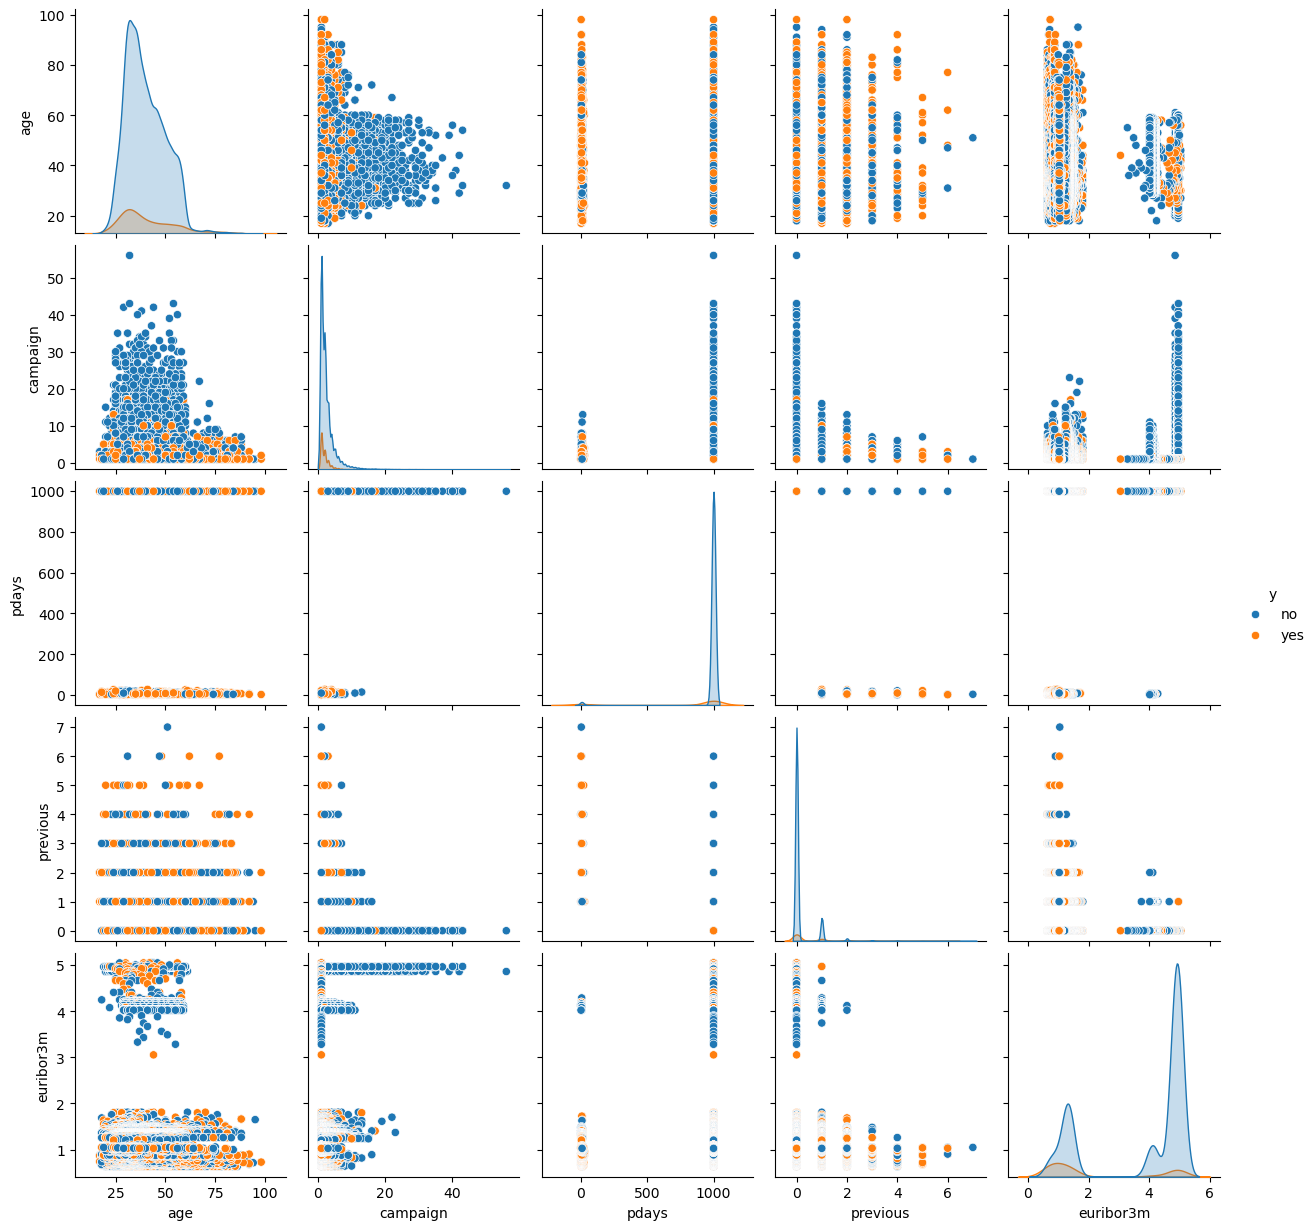

In [24]:
plt.figure(figsize=(10,6))
sns.pairplot(df[['age','campaign','pdays','previous','euribor3m','y']], hue='y')
plt.show()

**Insights:**

- Pairplot helps understand **multivariate relationships.**
- We observe clusters where low euribor rate leads to more subscriptions.
- Campaign and previous contacts show interesting patterns.

## Feature Engineering

In [25]:
# Separate target
df['y'] = df['y'].map({'yes':1, 'no':0})

**Insights:**

- converts the target variable (y) from **categorical text to numerical values(0/1).** 
- **Machine Learning models** can easily understand numbers like 1 and 0.
- .map() replaces values in 0 and 1 using a dictionary.

In [26]:
df['y'].value_counts()

y
0    36537
1     4639
Name: count, dtype: int64

### Encoding categorical variable

In [27]:
df = pd.get_dummies(df, drop_first=True)

**Insights:**

- Most categorical features in this dataset are nominal and do not have intrinsic order.
- Label encoding would introduce artificial ordinal relationships.
- Therefore, **One Hot Encoding was applied to prevent misleading** numerical hierarchy.
- We used One-Hot Encoding manually because machine learning models cannot understand text(categorical) values.

In [28]:
df['y'].value_counts()

y
0    36537
1     4639
Name: count, dtype: int64

### Feature & Target Split 

In [29]:
X = df.drop('y', axis=1)    # axis=1 is column detect
y = df['y']

**Insight:**

The dataset is divided into:
- Independent variables is (features,(X))
- Dependent variable ("y" ,(Y))

### Train-Test Split 

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(32940, 44)
(8236, 44)


**Insight:**

The dataset is split into:

- 80% training data
- 20% testing data
- Stratify ensures all price ranges are equally represented.

### Handle Imbalanced Data Using (SMOTE)

In [31]:
sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: y
0    29229
1     3711
Name: count, dtype: int64
After SMOTE: y
0    29229
1    29229
Name: count, dtype: int64


**Insight:**

- SMOTE creates synthetic minority samples.
- Now both classes balanced.
- This improves recall for minority class.
- Helps model learn patterns of “Yes” customers.
- SMOTE balances the dataset by creating synthetic minority samples.
- The dataset is highly imbalanced, with significantly more customers not subscribing to the term deposit than those who subscribed.

### Feature Scaling (Logistic Regression, SVM & KNN)

In [32]:
scaler = StandardScaler()

X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

**Insights:**

- SVM and KNN are distance-based models, Scaling ensure equal importance.
- Scaling prevents large value features dominating.
- Features must be on same scale.
- Scaling improves accuracy significantly.

## Model Building

### Logistic Regression

In [33]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_sm_scaled, y_train_sm)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Logistic Accuracy: 0.8386352598348713
Logistic ROC-AUC: 0.7283401928448748


**Insights:**

- Baseline linear model.
- Good for interpretability.
- Works well if relationship linear model.

### Decision Tree

In [34]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_sm, y_train_sm)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Decision Tree Accuracy: 0.8348712967459933
Decision Tree ROC-AUC: 0.6347299045212617


**Insights:**

- Non-linear model.
- Handles categorical-like features well.
- Can overfit if not tuned.

### Random Forest

In [35]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Accuracy: 0.8801602719766877
Random Forest ROC-AUC: 0.7767483349612139


**Insights:**

- Ensemble model of Random Forest model.
- Reduces overfitting.
- Usually **Random Forest model performs best.**

In [37]:
print(X_train_sm_scaled.shape)

(58458, 44)


### Support Vector Machine (SVM)

In [38]:
svm = SVC(kernel='linear', probability=True, max_iter=2000)

svm.fit(X_train_sm_scaled, y_train_sm)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

SVM Accuracy: 0.5267119961146187
SVM ROC-AUC: 0.47193889136609857


**Insight:**

- Powerful classifier.
- Works well with scaled data.
- Good at complex decision boundaries.
- Slightly slower but robust

### K-Nearest Neighbors (KNN)

In [39]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_sm_scaled, y_train_sm)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:,1]

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

KNN Accuracy: 0.8394851869839728
KNN ROC-AUC: 0.7255922595455147


**Insight:**

- Distance-based model.
- Sensitive to scaling.
- Works well with balanced dataset.

### XGBoost

In [40]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Accuracy: 0.8892666342884895
XGBoost ROC-AUC: 0.778432837537512


**XGBoost (with Hyperparameter Tuning)**

In [46]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5],
    'learning_rate':[0.01,0.1]
    }

grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

# Train model
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

# Tuned Model
best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("Tuned Accuracy:", accuracy_score(y_test, y_pred))
print("Tuned AUC:", roc_auc_score(y_test, y_prob)) 

# Model Evaluation
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Tuned Accuracy: 0.8988586692569208
Tuned AUC: 0.8108918780552253

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95      7308
           1       0.65      0.23      0.33       928

    accuracy                           0.90      8236
   macro avg       0.78      0.60      0.64      8236
weighted avg       0.88      0.90      0.88      8236


Confusion Matrix:
 [[7194  114]
 [ 719  209]]


**Insights:**

- Base XGBoost model achieved 88.9% Accuracy and 0.778 ROC-AUC, showing good prediction performance.
- The model can effectively distinguish between customers who will subscribe and those who will not.
- After hyperparameter tuning, the model performance improved.
- Tuned model achieved **89.8% Accuracy and 0.810 ROC-AUC.**
- Hyperparameter tuning improved model stability and generalization on test data.
- Tuned XGBoost provides more reliable predictions for identifying potential customers.
- Overall, XGBoost with **hyperparameter tuning performed better** than the default model.

**Why ROC-AUC is Mandatory**

- The bank marketing dataset is imbalanced (more “No” than “Yes” customers), so accuracy alone can be misleading.
- ROC-AUC measures **how well the model separates customers who will subscribe vs not subscribe.**
- It evaluates model performance across all thresholds, not just one prediction level.
- A higher ROC-AUC means the model correctly ranks likely subscribers higher than non-subscribers.
- Higher ROC-AUC means better customer prediction capability for marketing campaigns.

### ROC Curve (Best Model XGBoost)

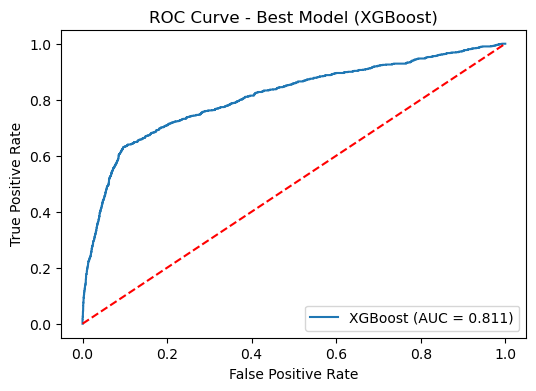

In [50]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="XGBoost (AUC = %0.3f)" % roc_auc_score(y_test, y_prob))
plt.plot([0,1], [0,1], 'r--')  # Random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model (XGBoost)")
plt.legend(loc="lower right")
plt.show()

**Insights:**

- ROC Curve graph, The curve should be **above the diagonal line, showing the model performs better** than random prediction.
- AUC ≈ 0.81, which indicates good classification performance.

#### Model Training

- Data was split into **training and testing sets** to evaluate model performance.
- SMOTE was applied on training data to handle class imbalance.
- Multiple models were trained such as **Logistic Regression, Decision Tree, Random Forest, SVM, KNN and XGBoost.**
- Each model was trained using the training dataset to learn patterns from customer data.
- Model performance was evaluated using Accuracy and ROC-AUC score.

In [55]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "KNN", "SVM", "XGBoost"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred)
    ],
    
    "ROC_AUC": [
        roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, svm.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])
    ]
})

results = results.sort_values(by="ROC_AUC", ascending=False)
results

,Model,Accuracy,ROC_AUC
5,XGBoost,0.898859,0.810892
2,Random Forest,0.880160,0.776748
0,Logistic Regression,0.838635,0.728340
3,KNN,0.839485,0.725592
1,Decision Tree,0.834871,0.634730
4,SVM,0.526712,0.471939


**Insights:**

- Logistic Regression = Works as a strong baseline model but struggles to capture complex patterns.
- Random Forest = Ensemble method that reduces overfitting and captures nonlinear relationships.
- Decision Tree = Decision Trees tend to overfit the training data, the model showed lower ROC-AUC performance compared to ensemble models like Random Forest and XGBoost.
- Support Vector Machine (SVM) =  Performs better than KNN but requires more computational resources.
- K-Nearest Neighbors (KNN) = Sensitive to feature scaling and performs weaker on large datasets.
- XGBoost (Tuned) = Achieved the highest ROC-AUC score and provided the best class separation performance.

## Final Model Selection

Selected Model: **Tuned XGBoost Model**

**Why XGBoost Model is Best?**

- XGBoost **achieved the highest ROC-AUC score (≈0.81)** among all models, showing better classification performance.
- It also produced **high accuracy (~89%),** indicating strong prediction capability.
- XGBoost handles complex patterns and feature interactions effectively using gradient boosting.
- The model improved after hyperparameter tuning, which increased both accuracy and ROC-AUC.
- XGBoost reduces overfitting through regularization and boosting techniques.
- The model showed stable and consistent performance on the test dataset.
- Therefore, XGBoost was selected as the final model for predicting customers likely to subscribe to a term deposit.


## Feature Importance

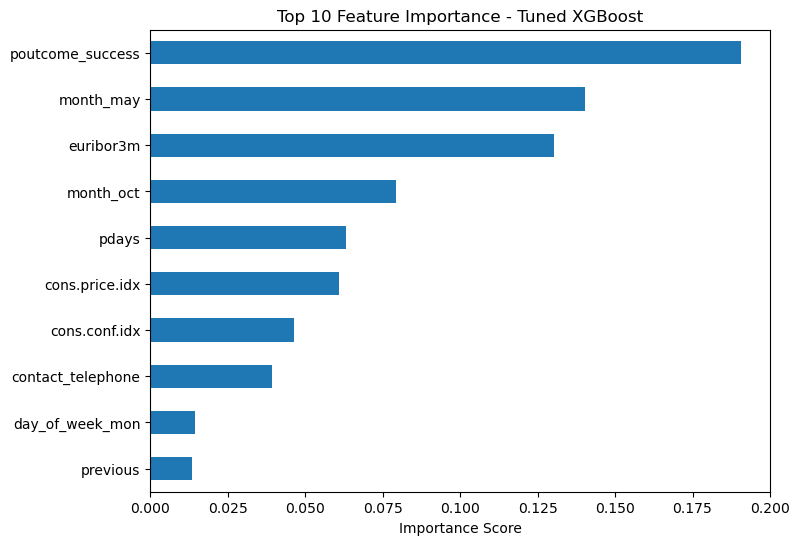

In [59]:
feature_imp = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values().tail(10)

plt.figure(figsize=(8,6))
feature_imp.plot(kind='barh')

plt.title("Top 10 Feature Importance - Tuned XGBoost")
plt.xlabel("Importance Score")

plt.show()

## Challenges Faced and Solutions

**1. Class Imbalance:**

Challenge: The dataset had more “No” responses than “Yes”, which can bias the model.

Solution: Applied SMOTE to balance the training data.

**2. Duration Feature Issue:**

Challenge: The duration **feature leaks information,** because it is known only after the call ends.

Solution: Removed the duration feature to build a realistic prediction model.

**3. Categorical Variables:**

Challenge: Many features **like job, education, marital status** were categorical.

Solution: Used encoding techniques (Label/One-Hot Encoding) to convert them into numerical format.

**4. Feature Scaling:**

Challenge: Algorithms like KNN and SVM require scaled data for better performance.

Solution: Applied StandardScaler to normalize the features.

**5. Model Selection:**

Challenge: Multiple models produced different results.

Solution: Compared models using Accuracy and ROC-AUC scores.

**6. Model Performance Improvement:**

Challenge: Default model parameters did not give the best results.

Solution: Used **GridSearchCV for hyperparameter tuning.**

**7. Overfitting Risk:**

Challenge: Some models like Decision Tree may overfit training data.

Solution: Used ensemble models like Random Forest and XGBoost which generalize better.

**8. Model Evaluation:**

Challenge: Accuracy alone is not reliable for imbalanced data.

Solution: Used ROC-AUC and ROC Curve for better model evaluation.

## Suggestions to the Bank Marketing Team

- **Target high-probability customers:**  Use the prediction model to identify customers who are more likely to subscribe to term deposits.

- **Focus on previous successful customers:**  Customers who responded positively in earlier campaigns have a higher chance of subscribing again.

- Use personalized communication:  Clearly **explain the benefits of term deposits based on the customer’s financial needs.**

- **Choose the right contact method:**  Prefer **cellular/mobile communication,** as it generally gives better response rates.

- **Provide attractive offers:**  Offer competitive interest rates or special benefits to encourage customers to invest in term deposits.

## Save Final model 

In [61]:
# Save the tuned XGBoost model
with open("final_xgboost_model.pkl", "wb") as file:
    pickle.dump(best_xgb, file)

print("Best XGBoost Model saved successfully.") 

Best XGBoost Model saved successfully.


In [62]:
# Load the Pickle Model Later
# with open("final_xgboost_model.pkl", "rb") as file:
 #    model = pickle.load(file)

## Conclusion

This project focused on **predicting whether a customer will subscribe to a term deposit** using machine learning techniques.
A complete data analysis process was performed including **data cleaning, exploratory data analysis, feature engineering, and model building.**

Several machine learning models such as **Logistic Regression, Decision Tree, Random Forest, KNN, SVM, and XGBoost** were trained and evaluated using 
Accuracy and ROC-AUC metrics. Since the dataset was imbalanced, ROC-AUC was considered an important metric for proper model evaluation.

Among all models, **XGBoost performed the best, achieving higher Accuracy and ROC-AUC compared to other algorithms.**
After applying hyperparameter tuning, the model performance improved further, making it more **reliable and stable** for prediction.

From a business perspective, the developed predictive model provides valuable support to the bank marketing team. By **identifying high-potential customers,** the bank can focus its marketing efforts more effectively, reduce unnecessary calls, and improve the overall success rate of marketing campaigns.

The final model can help the bank marketing team identify customers who are more likely to subscribe to term deposits.This enables the bank to focus
marketing efforts on high-potential customers, reduce unnecessary calls, and improve campaign success rates.

Overall, this project demonstrates how **data-driven machine learning models can support better marketing decisions and 
improve customer targeting strategies in the banking sector.**
